In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import describe


FUNCIONES AUXILIARES

In [39]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, shade=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
        plt.axvline(media, color='red', linestyle='--', label='Media')
 

    # Sombreado
    if mvd and shade:
        plt.axvspan(media - std, media + std, alpha=0.1, color='orange', label='±1 Std')
        plt.axvline(media + std, color='orange', linestyle=':', label='+1 Std')
        plt.axvline(media - std, color='orange', linestyle=':', label='-1 Std')
        plt.figtext(0.15, 0.80, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var:   {var:.2f}',   fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std:   {std:.2f}',   fontsize=10, color='orange')

    

    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()
    
    return

CARGA Y LIMPIEZA DE DATOS
Importo el archivo y reviso la cantidad de filas , columnas y datos faltantes. 
Aplicamos reglas de limpieza.

In [46]:
#CARGA DE DATOS
df_csv = pd.read_csv("datasets/player_stats.csv")

#visualizacion de datos , cantidad de filas y columnas totales
print("Cantidad de filas y columnas = " , df_csv.shape)

print("Columnas:" , df_csv.columns)

Cantidad de filas y columnas =  (1248, 21)
Columnas: Index(['player_id', 'player_name', 'team_id', 'position', 'matches_played',
       'matches_started', 'minutes_played', 'goals', 'assists', 'shots',
       'shots_on_target', 'yellow_cards', 'red_cards', 'penalty_goals',
       'own_goals', 'clean_sheets', 'saves', 'goals_conceded',
       'average_rating', 'data_source', 'last_verified'],
      dtype='str')


In [5]:
#Visualizacion de datos, estructura de los datos
df_csv. info()

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        1248 non-null   int64  
 1   player_name      1248 non-null   str    
 2   team_id          1248 non-null   int64  
 3   position         1248 non-null   str    
 4   matches_played   1248 non-null   int64  
 5   matches_started  1248 non-null   int64  
 6   minutes_played   1248 non-null   int64  
 7   goals            1248 non-null   int64  
 8   assists          1248 non-null   int64  
 9   shots            0 non-null      float64
 10  shots_on_target  0 non-null      float64
 11  yellow_cards     1248 non-null   int64  
 12  red_cards        1248 non-null   int64  
 13  penalty_goals    1248 non-null   int64  
 14  own_goals        1248 non-null   int64  
 15  clean_sheets     145 non-null    float64
 16  saves            145 non-null    float64
 17  goals_conceded   145 non-

VISUALIZACION DE DATOS NULOS

In [11]:
#Quiero ver la cantidad de datos nulos 
 #Si la celda esta vacia pone true (1)

nulos = df_csv.isnull().sum()

porcentaje_nulos = (nulos / len(df_csv))*100

tabla_nulos = pd.DataFrame({
    'cantidad de nulos' : nulos, 
    'Porcentaje': porcentaje_nulos
})
print(tabla_nulos)

                 cantidad de nulos  Porcentaje
player_id                        0    0.000000
player_name                      0    0.000000
team_id                          0    0.000000
position                         0    0.000000
matches_played                   0    0.000000
matches_started                  0    0.000000
minutes_played                   0    0.000000
goals                            0    0.000000
assists                          0    0.000000
shots                         1248  100.000000
shots_on_target               1248  100.000000
yellow_cards                     0    0.000000
red_cards                        0    0.000000
penalty_goals                    0    0.000000
own_goals                        0    0.000000
clean_sheets                  1103   88.381410
saves                         1103   88.381410
goals_conceded                1103   88.381410
average_rating                1248  100.000000
data_source                    209   16.746795
last_verified

Tratamiento de datos nulos


In [21]:
#Elimino columnas vacias (100%)
columnas_vacias = ['shots', 'shots_on_target', 'average_rating']
df_csv.drop(columns=columnas_vacias, inplace=True, errors='ignore')


# el 88% son datos de todos arqueros
columna_arquero = ['clean_sheets', 'saves' , 'goals_conceded']
df_csv[columna_arquero] = df_csv[columna_arquero].fillna(0)


#VERIFICO y uso el fillna para pasar los valores vacios a "sin especificar"

if 'data_source' in df_csv.columns:
    df_csv['data_source'] = df_csv['data_source'].fillna('Sin especificar')

columnas restantes en el dataset: ['player_id', 'player_name', 'team_id', 'position', 'matches_played', 'matches_started', 'minutes_played', 'goals', 'assists', 'yellow_cards', 'red_cards', 'penalty_goals', 'own_goals', 'clean_sheets', 'saves', 'goals_conceded', 'data_source', 'last_verified']
Cantidad de nulos 0


In [55]:

df_csv['position'] = df_csv['position'].astype('category')

print('columnas restantes en el dataset:' , df_csv.columns.to_list())

#ACA YA ELIMINE LOS DATOS NULOS, POR ESO TIRA 0
print('Cantidad de nulos', df_csv.isnull().sum().sum())

print("Cantidad de filas duplicadas: ", df_csv.duplicated().sum())

print(df_csv.dtypes)

columnas restantes en el dataset: ['player_id', 'player_name', 'team_id', 'position', 'matches_played', 'matches_started', 'minutes_played', 'goals', 'assists', 'shots', 'shots_on_target', 'yellow_cards', 'red_cards', 'penalty_goals', 'own_goals', 'clean_sheets', 'saves', 'goals_conceded', 'average_rating', 'data_source', 'last_verified', 'contribuciones_gol']
Cantidad de nulos 7262
Cantidad de filas duplicadas:  0
player_id                int64
player_name                str
team_id                  int64
position              category
matches_played           int64
matches_started          int64
minutes_played           int64
goals                    int64
assists                  int64
shots                  float64
shots_on_target        float64
yellow_cards             int64
red_cards                int64
penalty_goals            int64
own_goals                int64
clean_sheets           float64
saves                  float64
goals_conceded         float64
average_rating         

ANALISIS DE LOS DATOS
Variables numericas y categoricas
Para optimizar el análisis, convierto la variable "position" al tipo categorico.
Creo la metrica que va a ser contribuciones de gol.

In [49]:
# Ajuste de tipos de datos
df_csv['position'] = df_csv['position'].astype('category')

# Creacion de variable derivada 
df_csv['contribuciones_gol'] = df_csv['goals'] + df_csv['assists']

# Verificacion de filas duplicadas y tipos finales
print(f"Cantidad de filas duplicadas: {df_csv.duplicated().sum()}")
print("\nTipos de datos finales:")
print(df_csv.dtypes)

Cantidad de filas duplicadas: 0

Tipos de datos finales:
player_id                int64
player_name                str
team_id                  int64
position              category
matches_played           int64
matches_started          int64
minutes_played           int64
goals                    int64
assists                  int64
shots                  float64
shots_on_target        float64
yellow_cards             int64
red_cards                int64
penalty_goals            int64
own_goals                int64
clean_sheets           float64
saves                  float64
goals_conceded         float64
average_rating         float64
data_source                str
last_verified              str
contribuciones_gol       int64
dtype: object


ESTADISTICAS
Analizamos el comportamiento individual de las metricas principales:
-goles
-asistencias
-atajadas
-minutos

Media de goles:   0.24
Mediana de goles: 0.00
Moda de goles:    0.00
--RESUMEN ESTADISTICO NUMERICO--


,player_id,team_id,matches_played,matches_started,minutes_played,goals,assists,shots,shots_on_target,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,contribuciones_gol
count,1248.00,1248.00,1248.00,1248.00,1248.00,1248.00,1248.00,0.0,0.0,1248.00,1248.00,1248.0,1248.00,145.00,145.00,145.00,0.0,1248.00
mean,624.50,24.50,2.56,1.83,169.00,0.24,0.16,NaN,NaN,0.03,0.01,0.0,0.01,0.38,4.77,2.17,NaN,0.40
std,360.41,13.86,1.78,1.77,152.69,0.77,0.54,NaN,NaN,0.17,0.10,0.0,0.11,0.85,6.67,2.91,NaN,1.07
min,1.00,1.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0.00,0.00,0.00,NaN,0.00
25%,312.75,12.75,1.00,0.00,23.00,0.00,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0.00,0.00,0.00,NaN,0.00
50%,624.50,24.50,3.00,2.00,146.00,0.00,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0.00,0.00,0.00,NaN,0.00
75%,936.25,36.25,4.00,3.00,270.00,0.00,0.00,NaN,NaN,0.00,0.00,0.0,0.00,0.00,8.00,4.00,NaN,0.00
max,1248.00,48.00,8.00,8.00,750.00,10.00,8.00,NaN,NaN,1.00,1.00,0.0,2.00,5.00,29.00,10.00,NaN,14.00


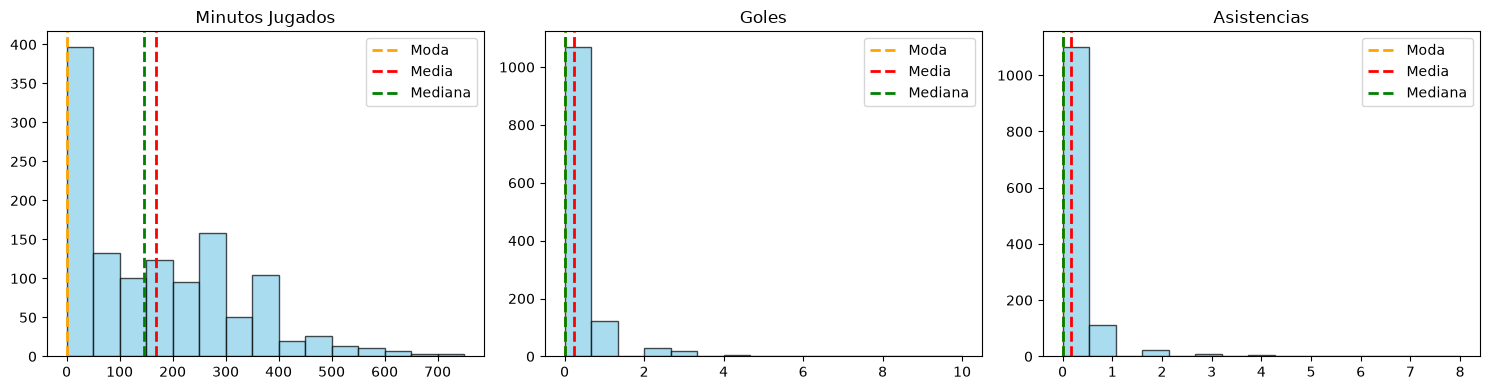

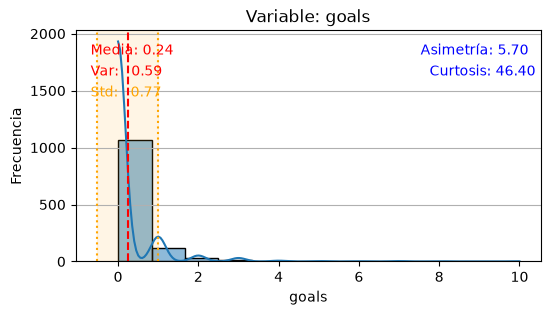

In [63]:
#Estadistica descriptiva
#Exploracion de variables numéricas

print(f"Media de goles:   {df_csv['goals'].mean():.2f}")
print(f"Mediana de goles: {df_csv['goals'].median():.2f}")
print(f"Moda de goles:    {df_csv['goals'].mode()[0]:.2f}")


print("--RESUMEN ESTADISTICO NUMERICO--")
display(df_csv.describe().round(2))


#histograma con media , mediana y moda
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

def plot_distribution(ax, data, title):
    ax.hist(data, bins=15, alpha=0.7, color='skyblue', edgecolor='black')
    ax.axvline(data.mode()[0], color='orange', linestyle='--', linewidth=2, label='Moda')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label='Media')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label='Mediana')
    ax.set_title(title)
    ax.legend()

plot_distribution(axes[0], df_csv['minutes_played'], 'Minutos Jugados')
plot_distribution(axes[1], df_csv['goals'], 'Goles')
plot_distribution(axes[2], df_csv['assists'], 'Asistencias')
plt.tight_layout()
plt.show()

#snk = Visualizo la forma de la curva para ver la asimetria
#mvd = media,varianza y desviacion estandar.
plot_histograma(df_csv , 'goals' , mvd=True , snk=True , bins=12)


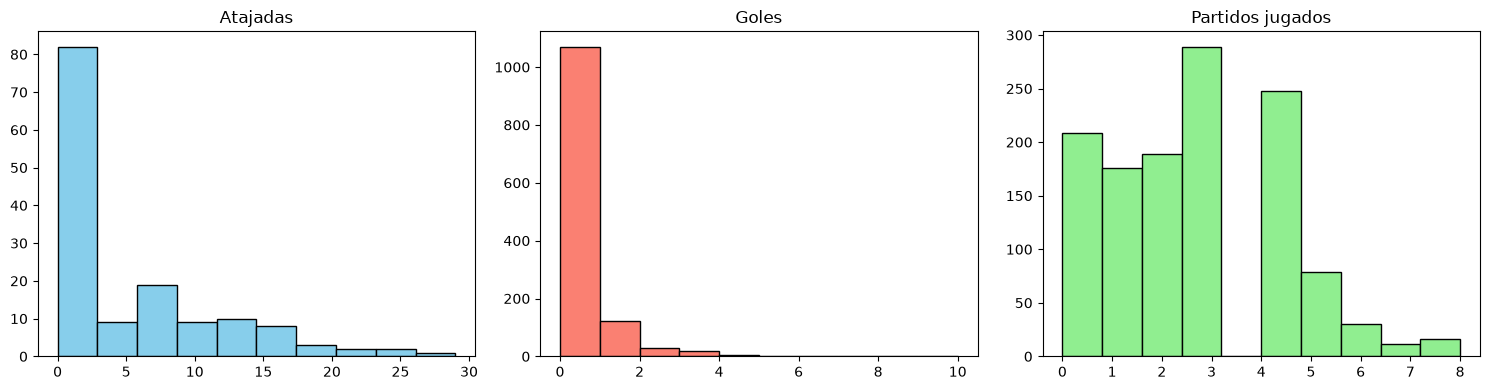

In [58]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(df_csv['saves'], bins=10, color='skyblue', edgecolor='black')
ax[0].set_title("Atajadas")

ax[1].hist(df_csv['goals'], bins=10, color='salmon', edgecolor='black')
ax[1].set_title('Goles')

ax[2].hist(df_csv['matches_played'], bins=10, color='lightgreen', edgecolor='black')
ax[2].set_title('Partidos jugados')
plt.tight_layout()
plt.show()

ANALISIS UNIVARIADO CATEGORICO
Evaluo como se distribuye el plantel segun la posicion en la cancha. 


--- Distribución Categórica: Posiciones---


,Cantidad de Jugadores,Porcentaje del Total (%)
position,,
DEF,421,33.73
MID,369,29.57
FWD,313,25.08
GK,145,11.62


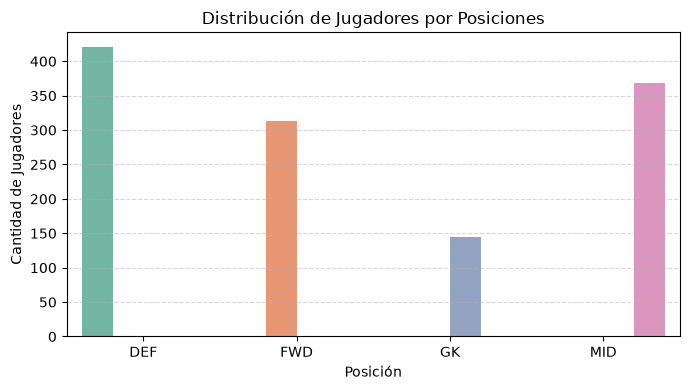

In [64]:
conteo = df_csv['position'].value_counts()
porcentaje = df_csv['position'].value_counts(normalize=True).mul(100).round(2)

tabla_posiciones = pd.DataFrame({
    'Cantidad de Jugadores': conteo,
    'Porcentaje del Total (%)': porcentaje
})

print("--- Distribucion Categórica: Posiciones---")
display(tabla_posiciones)

plt.figure(figsize=(7, 4))
sns.countplot(data=df_csv, x='position', palette='Set2', hue='position', legend=False)
plt.title('Distribución de Jugadores por Posiciones')
plt.xlabel('Posición')
plt.ylabel('Cantidad de Jugadores')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

RELACIONES ENTRE VARIABLES
Cruzo distintas variables para identificar patrones

/tmp/ipykernel_8575/2637391471.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


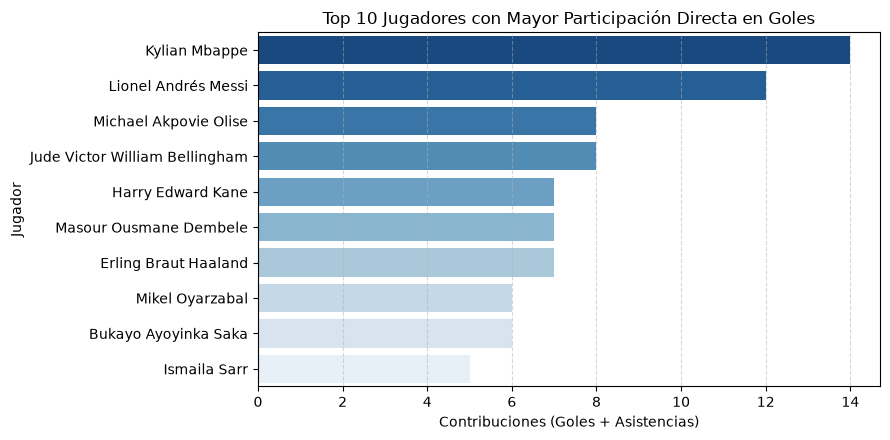

/tmp/ipykernel_8575/2637391471.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_csv, x='position', y='minutes_played', palette='Set2')


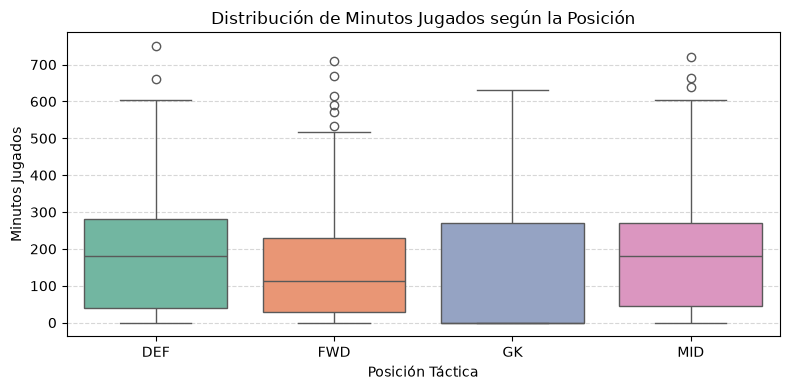

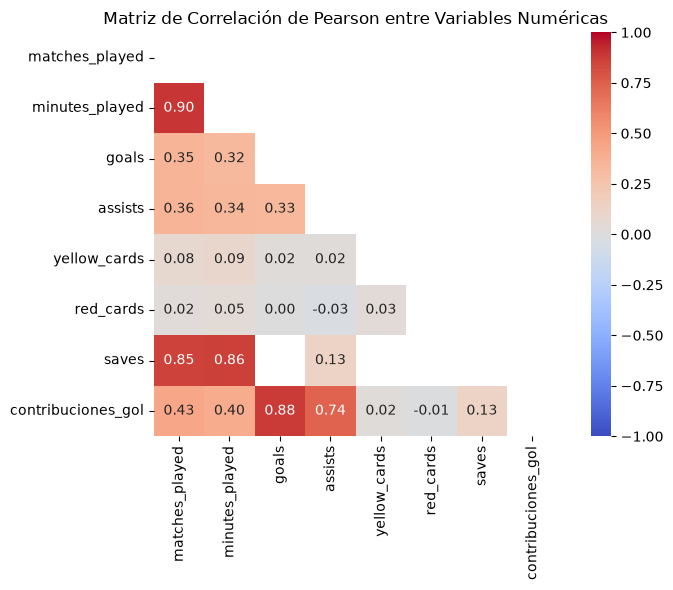

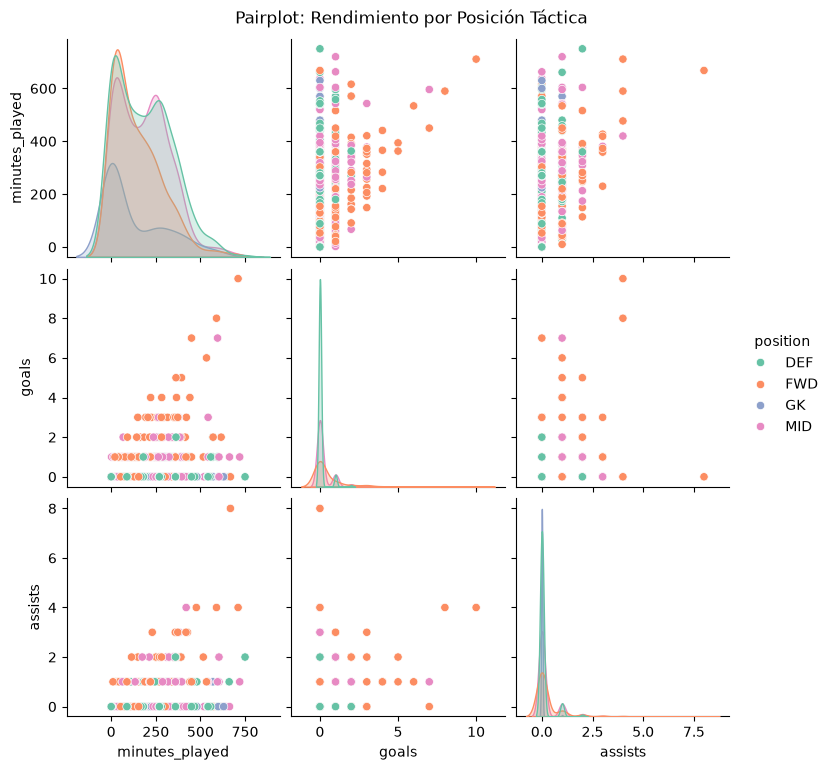

In [54]:
# Ranking de impacto: Top 10 Jugadores en Goles + Asistencias
top_goleadores = df_csv.sort_values(by='contribuciones_gol', ascending=False).head(10)

plt.figure(figsize=(9, 4.5))
sns.barplot(
    data=top_goleadores,
    x='contribuciones_gol',
    y='player_name',
    palette='Blues_r'
)
plt.title('Top 10 Jugadores con Mayor Participación Directa en Goles')
plt.xlabel('Contribuciones (Goles + Asistencias)')
plt.ylabel('Jugador')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Relación Categorica vs Numerica: Minutos por Posición
plt.figure(figsize=(8, 4))
sns.boxplot(data=df_csv, x='position', y='minutes_played', palette='Set2')
plt.title('Distribución de Minutos Jugados según la Posición')
plt.xlabel('Posición Táctica')
plt.ylabel('Minutos Jugados')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Matriz de Correlacion de Pearson
cols_num = ['matches_played', 'minutes_played', 'goals', 'assists', 'yellow_cards', 'red_cards', 'saves', 'contribuciones_gol']
corr_matrix = df_csv[cols_num].corr()
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, mask=mascara)
plt.title('Matriz de Correlación de Pearson entre Variables Numéricas')
plt.tight_layout()
plt.show()

#  Analisis Multivariado: Pairplot
grafico = sns.pairplot(data=df_csv, vars=['minutes_played', 'goals', 'assists'], hue='position', palette='Set2')
grafico.figure.suptitle('Pairplot: Rendimiento por Posición Táctica', y=1.02)
plt.show()